<a href="https://colab.research.google.com/github/ahmadsofian/Phishing-URL-Classifier-with-Explainable-AI-XAI-/blob/main/Phishing_Classifier_with_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

df = pd.read_csv("urldata.csv")

df.head(5)

,Unnamed: 0,url,label,result
0,0,https://www.google.com,benign,0
1,1,https://www.youtube.com,benign,0
2,2,https://www.facebook.com,benign,0
3,3,https://www.baidu.com,benign,0
4,4,https://www.wikipedia.org,benign,0


In [7]:
print(df["label"].value_counts())

label
benign       345738
malicious    104438
Name: count, dtype: int64




---



**Balance Sampling**


*   50/50 split ensures our baseline Tree classifier doesn't develop a bias toward predicting benign URLs simply because they outnumber malicious ones 3-to-1 in the raw data.



In [8]:
#Create a balanced sample for fast prototyping & SHAP
benign_sample = df[df["label"] == "benign"].sample(
    n=5000, random_state=42
)
malicious_sample = df[df["label"] == "malicious"].sample(
    n=5000, random_state=42
)

df_sample = (
    pd.concat([benign_sample, malicious_sample])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"\nSampled Shape: {df_sample.shape}")
print(df_sample["label"].value_counts())


Sampled Shape: (10000, 4)
label
malicious    5000
benign       5000
Name: count, dtype: int64




---



**Feature Engineering: Turning Strings into SOC Signals**
- Now we will write functions using Python's built-in urllib.parse, re (regular expressions), and math libraries to extract 5 core lexical features from every raw URL string.

In [9]:
import math
import re
from urllib.parse import urlparse


# 1. Shannon Entropy Calculation
def calculate_shannon_entropy(url):
  if not url:
    return 0.0
  entropy = 0.0
  for char in set(url):
    p_x = float(url.count(char)) / len(url)
    entropy += -p_x * math.log(p_x, 2)
  return entropy


# 2. IPv4 Hostname Check
def has_ip_address(netloc):
  ip_pattern = r"^(?:[0-9]{1,3}\.){3}[0-9]{1,3}$"
  return 1 if re.match(ip_pattern, netloc) else 0


# 3. Suspicious Special Character Count
def count_special_chars(url):
  return sum(url.count(c) for c in ["@", "-", "?", "=", "%"])


# 4. Master Feature Extraction Function
def extract_lexical_features(df, url_column="url"):
  data = df.copy()

  # Extract netloc (hostname/domain area) using urlparse
  data["netloc"] = data[url_column].apply(lambda x: urlparse(x).netloc)

  # Core Features
  data["url_length"] = data[url_column].apply(len)
  data["hostname_length"] = data["netloc"].apply(len)
  data["has_ip"] = data["netloc"].apply(has_ip_address)
  data["special_chars"] = data[url_column].apply(count_special_chars)
  data["entropy"] = data[url_column].apply(
      lambda x: round(calculate_shannon_entropy(x), 3)
  )

  # Drop temporary columns
  data = data.drop(columns=["netloc"])
  return data


# Apply pipeline to our sampled DataFrame
df_features = extract_lexical_features(df_sample)

In [10]:
df_features.head(5)

,Unnamed: 0,url,label,result,url_length,hostname_length,has_ip,special_chars,entropy
0,427886,http://mensloungebarber.com/Update/?ID=login&amp,malicious,1,48,20,0,2,4.491
1,219278,https://www.imdb.com/title/tt0499549/,benign,0,37,12,0,0,4.003
2,50855,https://www.gees.usc.edu/GEES/,benign,0,30,16,0,0,3.806
3,145278,https://www.azcentral.com/thingstodo/music/art...,benign,0,130,17,0,8,4.631
4,185322,https://www.facebook.com/bernice.achiaa,benign,0,39,16,0,0,4.060




---



**Model Training: Building a Baseline Decision Tree**

*   We will train a Random Forest Classifier using Scikit-Learn. Decision trees are ideal for tabular lexical features because they capture non-linear thresholds well (e.g., "if length > 75 AND entropy > 4.5, then flag as Phishing").



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. Define feature matrix (X) and binary target label (y)
feature_cols = [
    "url_length",
    "hostname_length",
    "has_ip",
    "special_chars",
    "entropy",
]
X = df_features[feature_cols]
y = (df_features["label"] == "malicious").astype(
    int
)  # 1 = Phishing, 0 = Benign

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train the Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42
)
rf_model.fit(X_train, y_train)

# 4. Evaluate Performance
y_pred = rf_model.predict(X_test)
print(
    classification_report(y_test, y_pred, target_names=["Benign", "Phishing"])
)

              precision    recall  f1-score   support

      Benign       0.69      0.81      0.75      1000
    Phishing       0.77      0.64      0.70      1000

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.72      2000
weighted avg       0.73      0.73      0.72      2000



Feature Importance

In [14]:
import pandas as pd

# 1. Ensure you have your list of feature names exactly as ordered in X
feature_cols = [
    "url_length",
    "hostname_length",
    "has_ip",
    "special_chars",
    "entropy",
]

# 2. Create a DataFrame combining feature names and their importance scores
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_,
})

# 3. Sort from highest importance to lowest and format as percentages
importance_df = importance_df.sort_values(
    by="Importance", ascending=False
).reset_index(drop=True)
importance_df["Importance (%)"] = (importance_df["Importance"] * 100).round(2)

print("--- Random Forest Global Feature Importance ---")
print(importance_df[["Feature", "Importance (%)"]].to_string(index=False))

--- Random Forest Global Feature Importance ---
        Feature  Importance (%)
     url_length           29.72
hostname_length           28.19
        entropy           25.84
  special_chars           14.10
         has_ip            2.14




---



**Model Explainability: Why Was This URL Flagged?**

- Global importance tells us how the model behaves on average. But when an alert lands in a SOC queue, an analyst needs Local Explainability: "Why did the model flag THIS specific URL as Phishing with 91% confidence?"
- We will use SHAP (TreeExplainer) to generate a Waterfall Plot for a single phishing prediction.



--- Alert Feature Values ---
url_length         36.000
hostname_length    16.000
has_ip              0.000
special_chars       0.000
entropy             3.917
Name: 6855, dtype: float64


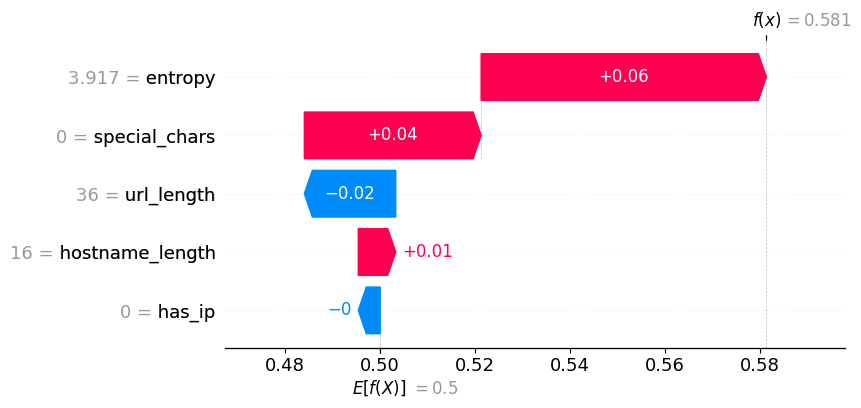

In [13]:
import pandas as pd
import shap

# 1. Initialize the SHAP TreeExplainer with our trained model
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for the test set
shap_values = explainer(X_test)

# 3. Select a specific flagged phishing URL from our test set
# (Let's assume index 4 is a true positive Phishing alert)
sample_idx = 4
flagged_features = X_test.iloc[sample_idx]
print("--- Alert Feature Values ---")
print(flagged_features)

# 4. Generate a Waterfall Plot for Class 1 (Phishing)
shap.plots.waterfall(shap_values[sample_idx, :, 1])